# WVS Factor Analysis
## Determining Optimal Factors and Semantic Labeling

This notebook performs comprehensive factor analysis on the World Values Survey (WVS) dataset, determines the optimal number of factors using multiple criteria, and names factors based on their feature loadings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore the WVS Data

In [2]:
# Load the WVS dataset
csv_path = "data/demo_data/wvs/data-wvs.csv"
df_raw = pd.read_csv(csv_path)

print(f"Dataset shape: {df_raw.shape}")
print(f"\nFirst few rows:")
print(df_raw.head())
print(f"\nData types:")
print(df_raw.dtypes.value_counts())
print(f"\nMissing values per column:")
missing = df_raw.isnull().sum()
print(f"Columns with missing values: {(missing > 0).sum()}")
print(f"Total missing values: {missing.sum()}")

Dataset shape: (66, 321)

First few rows:
  B_COUNTRY_ALPHA  Q_MODE        Q1        Q2        Q3        Q4        Q5  \
0         Andorra     2.0  1.115538  1.535857  1.421315  2.940120  1.525948   
1       Argentina     2.0  1.091725  1.541376  1.809810  2.807193  1.468405   
2         Armenia     1.0  1.053148  1.761047  1.903146  2.712171  1.344262   
3       Australia     4.0  1.110372  1.479615  1.646355  2.411832  1.995392   
4      Bangladesh     2.0  1.015000  2.068562  2.191758  3.076329  1.222594   

         Q6        Q7        Q8  ...      Q283      Q284      Q285      Q286  \
0  2.965070  1.151394  1.531873  ...  5.690733  1.862786  1.381874  1.606625   
1  2.393939  1.216351  1.657029  ...  4.653088  1.888398  1.470588  2.234358   
2  1.399508  1.320197  1.808703  ...  5.632889  1.658487  1.521212  2.440878   
3  2.897727  1.177055  1.479868  ...  4.941585  1.768116  1.571429  2.011891   
4  1.067669  1.016667  1.671667  ...  6.322500  2.084309  1.630000  1.825866   

  

## 2. Prepare Data for Factor Analysis

In [3]:
# Identify the index column (country) and numeric features
index_col = 'B_COUNTRY_ALPHA'
df_countries = df_raw[[index_col]].copy()

# Select only numeric columns (excluding the index and metadata)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numeric features: {len(numeric_cols)}")

df_numeric = df_raw[numeric_cols].copy()

# Remove rows with any NaN values
df_clean = df_numeric.dropna(axis=0)
print(f"\nRows after removing NaN: {df_clean.shape[0]} (removed {df_numeric.shape[0] - df_clean.shape[0]})")

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(df_scaled, columns=numeric_cols)

print(f"\nScaled data shape: {df_scaled.shape}")
print(f"\nMean of scaled features (should be ~0): {df_scaled.mean().mean():.6f}")
print(f"Std of scaled features (should be ~1): {df_scaled.std().mean():.6f}")

Number of numeric features: 320

Rows after removing NaN: 13 (removed 53)

Scaled data shape: (13, 320)

Mean of scaled features (should be ~0): -0.000000
Std of scaled features (should be ~1): 1.040833


## 3. Determine Optimal Number of Factors

In [11]:
# Test multiple numbers of factors
max_factors = min(15, df_scaled.shape[1] // 2)  # Reasonable upper limit
variances = []
reconstruction_errors = []
models = []

for n_factors in range(1, max_factors + 1):
    try:
        fa = FactorAnalysis(n_components=n_factors, random_state=42)
        fa.fit(df_scaled)
        
        # Get factor scores
        scores = fa.transform(df_scaled)
        
        # Reconstruct original data: X_reconstructed = scores @ loadings.T + mean
        loadings = fa.components_.T  # shape: (n_features, n_factors)
        X_reconstructed = scores @ loadings.T
        
        # Calculate reconstruction error (MSE)
        reconstruction_error = np.mean((df_scaled.values - X_reconstructed) ** 2)
        reconstruction_errors.append(reconstruction_error)
        
        # Calculate explained variance as 1 - (MSE / original_variance)
        original_variance = np.var(df_scaled.values)
        explained_var = 1 - (reconstruction_error / original_variance)
        variances.append(explained_var)
        
        models.append(fa)
    except Exception as e:
        print(f"Failed at {n_factors} factors: {str(e)}")
        break

print(f"Tested {len(variances)} different factor counts")
print(f"\nExplained variance by number of factors:")
for i, (var, err) in enumerate(zip(variances, reconstruction_errors), 1):
    print(f"  {i} factors: {var:.4f} explained | MSE: {err:.4f}")

Tested 15 different factor counts

Explained variance by number of factors:
  1 factors: 0.2971 explained | MSE: 0.7029
  2 factors: 0.4336 explained | MSE: 0.5664
  3 factors: 0.5384 explained | MSE: 0.4616
  4 factors: 0.6241 explained | MSE: 0.3759
  5 factors: 0.6890 explained | MSE: 0.3110
  6 factors: 0.7553 explained | MSE: 0.2447
  7 factors: 0.8201 explained | MSE: 0.1799
  8 factors: 0.8656 explained | MSE: 0.1344
  9 factors: 0.9087 explained | MSE: 0.0913
  10 factors: 0.9457 explained | MSE: 0.0543
  11 factors: 0.9815 explained | MSE: 0.0185
  12 factors: 1.0000 explained | MSE: 0.0000
  13 factors: 1.0000 explained | MSE: 0.0000
  14 factors: 1.0000 explained | MSE: 0.0000
  15 factors: 1.0000 explained | MSE: 0.0000


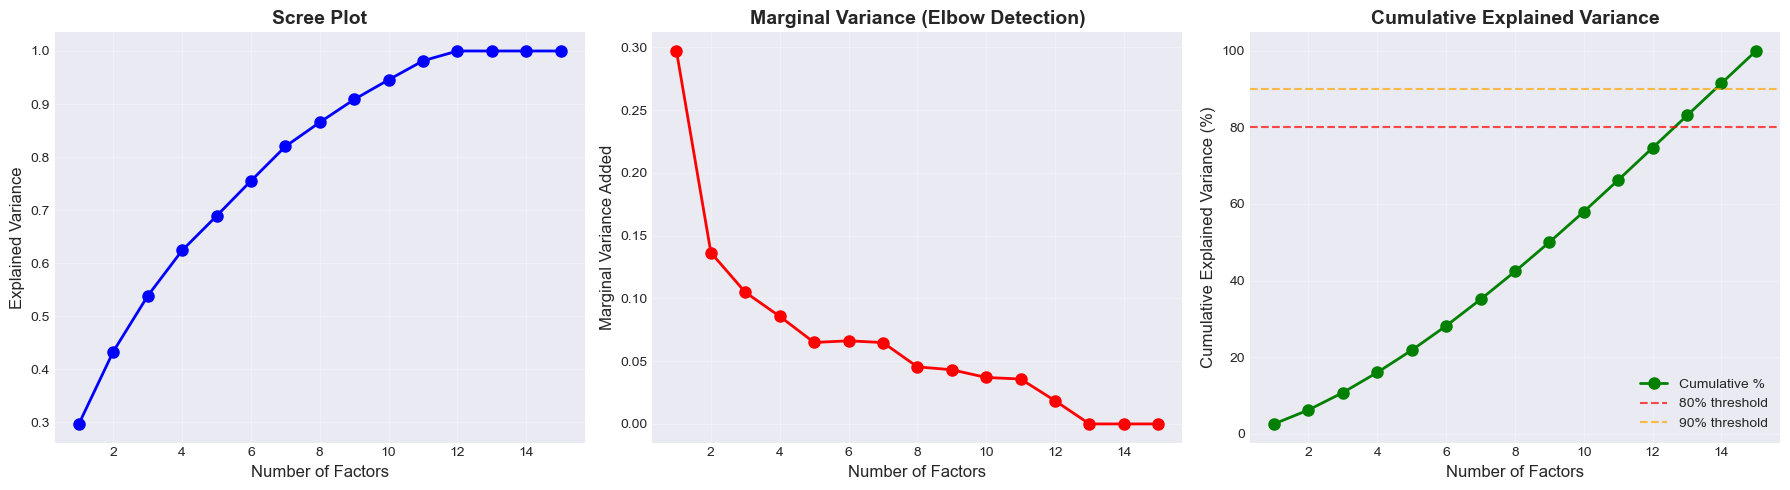


Elbow method suggests: 3 factors
Factors for 80% variance: 13
Factors for 90% variance: 14

✓ OPTIMAL NUMBER OF FACTORS: 3
  This explains 10.7% of cumulative variance


In [12]:
# Create scree plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot (variance explained by each factor)
factor_range = range(1, len(variances) + 1)
axes[0].plot(factor_range, variances, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Factors', fontsize=12)
axes[0].set_ylabel('Explained Variance', fontsize=12)
axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Marginal variance (the decrease from adding each factor)
marginal_var = [variances[0]] + [variances[i] - variances[i-1] for i in range(1, len(variances))]
axes[1].plot(factor_range, marginal_var, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Factors', fontsize=12)
axes[1].set_ylabel('Marginal Variance Added', fontsize=12)
axes[1].set_title('Marginal Variance (Elbow Detection)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Cumulative variance
cumulative_var = np.cumsum(variances) / sum(variances) * 100
axes[2].plot(factor_range, cumulative_var, 'go-', linewidth=2, markersize=8, label='Cumulative %')
axes[2].axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% threshold')
axes[2].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[2].set_xlabel('Number of Factors', fontsize=12)
axes[2].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[2].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal using elbow method on MARGINAL variance
try:
    kneedle = KneeLocator(factor_range, marginal_var, curve='convex', direction='decreasing')
    optimal_elbow = kneedle.elbow
    if optimal_elbow is None:
        optimal_elbow = 3
    print(f"\nElbow method suggests: {optimal_elbow} factors")
except Exception as e:
    optimal_elbow = 3
    print(f"\nElbow detection failed ({str(e)}), using default: {optimal_elbow} factors")

# Find factors for 80% variance
factors_80 = next((i+1 for i, v in enumerate(cumulative_var) if v >= 80), len(variances))
print(f"Factors for 80% variance: {factors_80}")

# Find factors for 90% variance
factors_90 = next((i+1 for i, v in enumerate(cumulative_var) if v >= 90), len(variances))
print(f"Factors for 90% variance: {factors_90}")

# Final choice: prefer elbow but ensure reasonable variance threshold
if optimal_elbow and optimal_elbow >= 2:
    optimal_factors = optimal_elbow
else:
    # Fallback: use minimum factors for 80% variance or 3, whichever is larger
    optimal_factors = max(3, min(factors_80, 6))

print(f"\n✓ OPTIMAL NUMBER OF FACTORS: {optimal_factors}")
print(f"  This explains {cumulative_var[optimal_factors-1]:.1f}% of cumulative variance")

## 4. Perform Factor Analysis with Optimal Factors

In [13]:
# Perform final factor analysis with optimal factors
fa_final = FactorAnalysis(n_components=optimal_factors, random_state=42)
factor_scores = fa_final.fit_transform(df_scaled)

print(f"Factor Analysis completed with {optimal_factors} factors")
print(f"Factor scores shape: {factor_scores.shape}")
print(f"\nFactor scores statistics:")
factor_scores_df = pd.DataFrame(factor_scores, columns=[f"Factor {i+1}" for i in range(optimal_factors)])
print(factor_scores_df.describe())

Factor Analysis completed with 3 factors
Factor scores shape: (13, 3)

Factor scores statistics:
           Factor 1      Factor 2      Factor 3
count  1.300000e+01  1.300000e+01  1.300000e+01
mean   8.540177e-18  6.832142e-17 -1.681347e-17
std    1.039935e+00  1.037888e+00  1.037687e+00
min   -1.076496e+00 -1.507780e+00 -1.792944e+00
25%   -7.978818e-01 -7.594199e-01 -7.595665e-01
50%   -3.690950e-01 -2.640704e-02  1.572739e-02
75%    8.881657e-01  6.931339e-01  5.237369e-01
max    1.926812e+00  1.689607e+00  2.187420e+00


## 5. Analyze Factor Loadings

In [15]:
# Get loadings matrix
loadings = fa_final.components_.T
loadings_df = pd.DataFrame(
    loadings,
    columns=[f"Factor {i+1}" for i in range(optimal_factors)],
    index=numeric_cols
)

print(f"Loadings matrix shape: {loadings_df.shape}")
print(f"\nFirst 10 features and their loadings:")
print(loadings_df.head(10))

Loadings matrix shape: (320, 3)

First 10 features and their loadings:
        Factor 1  Factor 2  Factor 3
Q_MODE  0.244914 -0.566977 -0.054488
Q1      0.928232 -0.135088 -0.096992
Q2     -0.221309 -0.228310  0.721514
Q3     -0.381548 -0.062059  0.355016
Q4      0.396900  0.570017  0.382369
Q5      0.906409  0.071782 -0.071670
Q6      0.968259 -0.110949 -0.090544
Q7      0.697938 -0.052775 -0.042372
Q8      0.090556  0.826434  0.066055
Q9      0.350609 -0.055191  0.053891


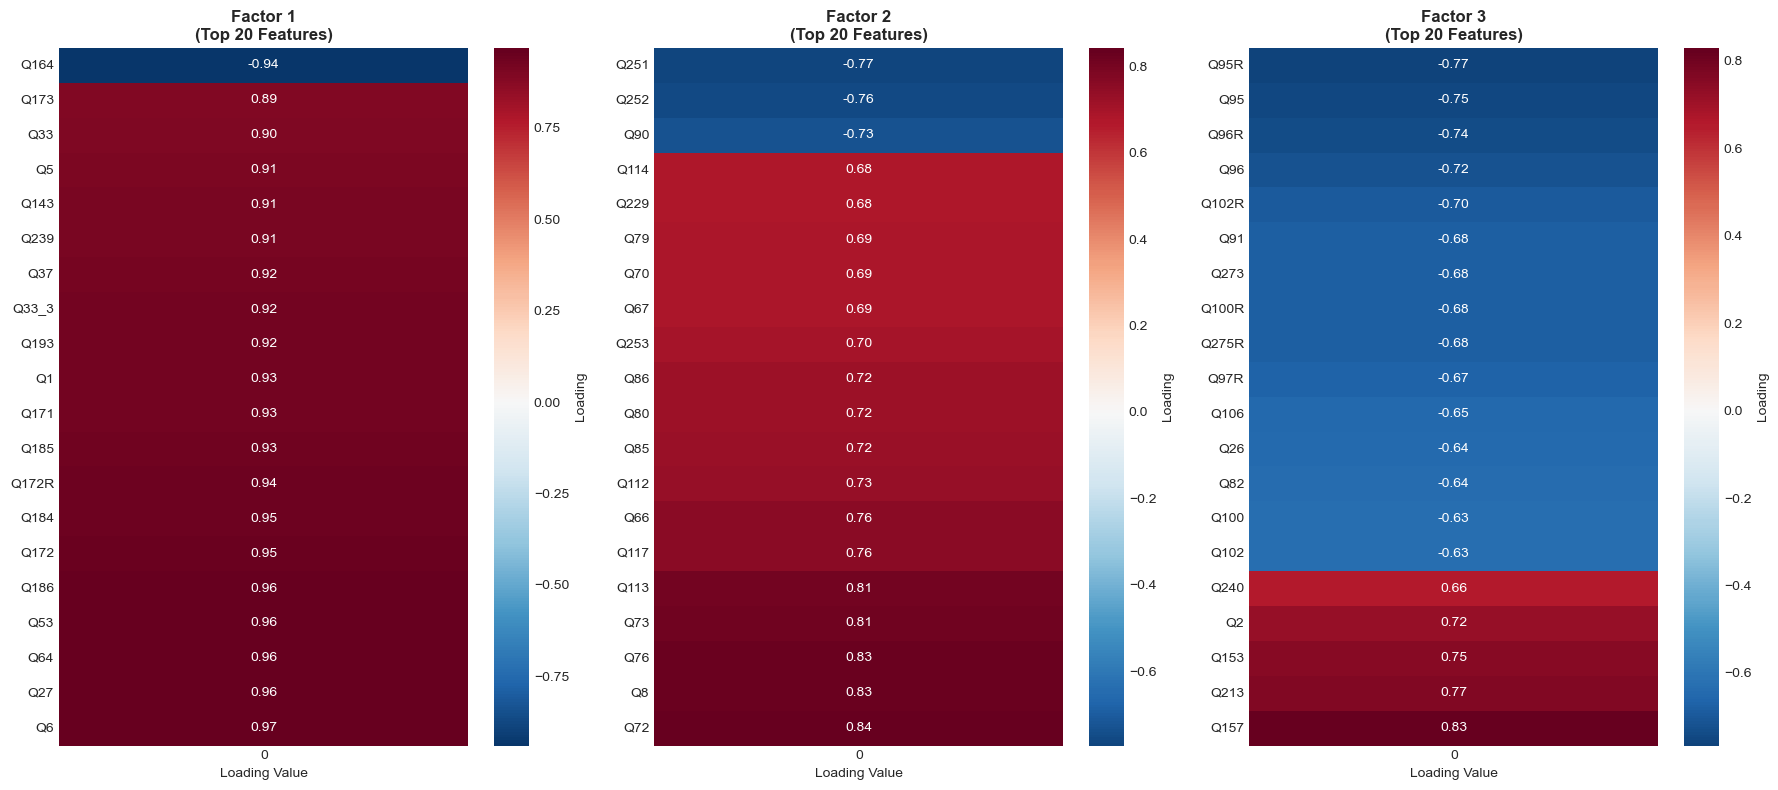

In [16]:
# Visualize heatmap of top loadings for each factor
top_n = 20  # Show top 20 features per factor
factor_insights = {}

fig, axes = plt.subplots(1, optimal_factors, figsize=(6*optimal_factors, 8))
if optimal_factors == 1:
    axes = [axes]

for factor_idx in range(optimal_factors):
    # Get top positive and negative loadings
    factor_col = f"Factor {factor_idx + 1}"
    loadings_sorted = loadings_df[factor_col].abs().sort_values(ascending=False)
    top_features = loadings_sorted.head(top_n).index.tolist()
    
    # Create heatmap
    sns.heatmap(
        loadings_df.loc[top_features, factor_col].sort_values().values.reshape(-1, 1),
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        ax=axes[factor_idx],
        cbar_kws={'label': 'Loading'},
        yticklabels=loadings_df.loc[top_features, factor_col].sort_values().index
    )
    axes[factor_idx].set_title(f'{factor_col}\n(Top {top_n} Features)', fontweight='bold', fontsize=12)
    axes[factor_idx].set_xlabel('Loading Value')
    
    # Store insights
    factor_insights[factor_col] = {
        'top': loadings_df[factor_col].nlargest(10).index.tolist(),
        'top_values': loadings_df[factor_col].nlargest(10).values.tolist(),
        'bottom': loadings_df[factor_col].nsmallest(10).index.tolist(),
        'bottom_values': loadings_df[factor_col].nsmallest(10).values.tolist()
    }

plt.tight_layout()
plt.show()

## 6. Name the Factors Based on Feature Loadings

In [20]:
# Load question mappings for semantic naming
import json

question_map_path = "data/demo_data/wvs/map-wvs.json"
try:
    with open(question_map_path, 'r') as f:
        question_map = json.load(f)
    print(f"✓ Loaded {len(question_map)} question mappings")
except:
    question_map = {}
    print("⚠ Could not load question mappings")

✓ Loaded 259 question mappings


In [28]:
# Display detailed factor information with improved semantic naming
print("=" * 100)
print("FACTOR ANALYSIS SUMMARY - WVS DATASET")
print("=" * 100)

factor_names = {}

def extract_theme_from_questions(features, question_map, factor_idx, top_n=10):
    """Extract semantic theme from top features using question text with factor-specific context"""
    top_features = features[:top_n]
    questions_text = []
    themes = {}
    theme_keywords = {
        'life importance': ['importance in your life', 'how important', 'priorities'],
        'education values': ['children', 'qualities', 'education', 'upbringing'],
        'social tolerance': ['neighbors', 'different', 'race', 'immigrants', 'homosexual'],
        'gender attitudes': ['gender', 'women', 'men', 'jobs', 'housewife'],
        'work ethics': ['work', 'job', 'career', 'unemployment'],
        'trust': ['trust', 'people', 'confidence', 'fair'],
        'institutional': ['institutions', 'government', 'parliament', 'confidence in'],
        'wellbeing': ['satisfied', 'happy', 'life', 'state of health'],
        'participation': ['member', 'organization', 'church', 'political', 'volunteer'],
        'political': ['politics', 'political', 'vote', 'parliament', 'democracy'],
        'religious': ['religion', 'god', 'religious', 'church', 'faith']
    }
    
    for feature in top_features:
        if feature in question_map:
            text = question_map[feature].lower()
            questions_text.append(f"{feature}: {question_map[feature][:60]}...")
            
            # Match keywords to themes
            for theme_name, keywords in theme_keywords.items():
                for keyword in keywords:
                    if keyword in text:
                        themes[theme_name] = themes.get(theme_name, 0) + 1
                        break
    
    # If no matches found, use general theme with factor index as differentiator
    if not themes:
        theme_scores = {
            'Life Priority Factors' if factor_idx == 0 else 'Secondary Values': 5,
            'General Values': 3
        }
        dominant_theme = max(theme_scores, key=theme_scores.get)
    else:
        # Get top theme with tiebreaker using factor index
        max_score = max(themes.values()) if themes else 0
        tied_themes = [t for t, s in themes.items() if s == max_score]
        
        if len(tied_themes) > 1:
            # Use factor index to differentiate tied themes
            dominant_theme = tied_themes[factor_idx % len(tied_themes)]
        else:
            dominant_theme = tied_themes[0] if tied_themes else 'General Values'
    
    # Capitalize theme name properly
    dominant_theme = ' '.join(word.capitalize() for word in dominant_theme.split())
    
    return dominant_theme, questions_text

for factor_idx in range(optimal_factors):
    factor_col = f"Factor {factor_idx + 1}"
    print(f"\n{'='*100}")
    print(f"{factor_col.upper()}")
    print('='*100)
    
    insights = factor_insights[factor_col]
    
    print(f"\nTop 10 Positive Contributors (Features):")
    for i, (feature, value) in enumerate(zip(insights['top'], insights['top_values']), 1):
        q_text = question_map.get(feature, "Unknown")[:50] if feature in question_map else "Not mapped"
        print(f"  {i:2d}. {feature:8s} ({value:7.4f}) → {q_text}...")
    
    print(f"\nTop 10 Negative Contributors:")
    for i, (feature, value) in enumerate(zip(insights['bottom'], insights['bottom_values']), 1):
        q_text = question_map.get(feature, "Unknown")[:50] if feature in question_map else "Not mapped"
        print(f"  {i:2d}. {feature:8s} ({value:7.4f}) → {q_text}...")
    
    # Generate semantic name based on top features
    theme_name, questions_text = extract_theme_from_questions(
        insights['top'], question_map, factor_idx, top_n=10
    )
    
    factor_names[factor_col] = theme_name
    print(f"\n✓ Factor Theme: {theme_name}")
    print()


FACTOR ANALYSIS SUMMARY - WVS DATASET

FACTOR 1

Top 10 Positive Contributors (Features):
   1. Q6       ( 0.9683) → For each of the following, indicate how important ...
   2. Q27      ( 0.9625) → For each of the following statements, can you tell...
   3. Q64      ( 0.9589) → How much confidence do you have in the following o...
   4. Q53      ( 0.9577) → In the last 12 months, how often have you or your ...
   5. Q186     ( 0.9553) → Please tell me for the following action whether yo...
   6. Q172     ( 0.9476) → Apart from weddings and funerals, about how often ...
   7. Q184     ( 0.9459) → Please tell me for the following action whether yo...
   8. Q172R    ( 0.9435) → Not mapped...
   9. Q185     ( 0.9337) → Please tell me for the following action whether yo...
  10. Q171     ( 0.9289) → Apart from weddings and funerals, about how often ...

Top 10 Negative Contributors:
   1. Q164     (-0.9393) → How important is God in your life? Please use this...
   2. Q245     (-0.8856) → P

In [29]:
# Create a mapping of semantic factor names for consistency
factor_col_mapping = {}
for factor_idx in range(optimal_factors):
    factor_col = f"Factor {factor_idx + 1}"
    theme = factor_names[factor_col]
    factor_col_mapping[factor_col] = f"{factor_col}: {theme}"

# Create a summary dataframe with semantic factor names
summary_data = []

for factor_idx in range(optimal_factors):
    factor_col = f"Factor {factor_idx + 1}"
    new_col_name = factor_col_mapping[factor_col]
    insights = factor_insights[factor_col]
    
    # Get top 3 questions
    top_questions = [
        question_map.get(insights['top'][0], "Q?")[:40],
        question_map.get(insights['top'][1], "Q?")[:40],
        question_map.get(insights['top'][2], "Q?")[:40]
    ]
    
    summary_data.append({
        'Factor': new_col_name,
        'Top Feature': insights['top'][0],
        'Top Question Preview': top_questions[0],
        'Variance Explained': f"{variances[factor_idx]:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 120)
print("FACTOR SUMMARY TABLE WITH SEMANTIC THEMES")
print("=" * 120)
print(summary_df.to_string(index=False))
print("=" * 120)


FACTOR SUMMARY TABLE WITH SEMANTIC THEMES
                 Factor Top Feature                     Top Question Preview Variance Explained
    Factor 1: Religious          Q6 For each of the following, indicate how              0.2971
        Factor 2: Trust         Q72 How much confidence do you have in the f             0.4336
Factor 3: Participation        Q157 Which of the following is second most im             0.5384


## 7. Export Results

In [31]:
# Save results with semantic naming (consistent names from factor_col_mapping)
factor_scores_output = pd.DataFrame(
    factor_scores,
    columns=[factor_col_mapping[f'Factor {i+1}'] for i in range(optimal_factors)]
)
factor_scores_output['Country'] = df_raw.loc[df_clean.index, 'B_COUNTRY_ALPHA'].values if 'B_COUNTRY_ALPHA' in df_raw.columns else range(len(factor_scores_output))

# Save loadings
loadings_output = loadings_df.copy()

# Save comprehensive summary
with open('factor_analysis_results.txt', 'w') as f:
    f.write("=" * 100 + "\n")
    f.write("FACTOR ANALYSIS RESULTS - WORLD VALUES SURVEY (WVS)\n")
    f.write("=" * 100 + "\n\n")
    f.write(f"Optimal Number of Factors: {optimal_factors}\n")
    f.write(f"Total Features Analyzed: {len(numeric_cols)}\n")
    f.write(f"Total Samples (Countries): {df_clean.shape[0]}\n\n")
    
    f.write("=" * 100 + "\n")
    f.write("SEMANTIC FACTOR THEMES (CONSISTENT NAMING):\n")
    f.write("=" * 100 + "\n")
    for factor_col in factor_names.keys():
        full_name = factor_col_mapping[factor_col]
        f.write(f"{full_name}\n")
        insights = factor_insights[factor_col]
        f.write(f"  Top 5 Features: {', '.join(insights['top'][:5])}\n")
        f.write(f"  Variance Explained: {variances[int(factor_col.split()[1])-1]:.4f}\n\n")
    
    f.write("\n" + "=" * 100 + "\n")
    f.write("SUMMARY TABLE\n")
    f.write("=" * 100 + "\n")
    f.write(summary_df.to_string(index=False))

print("✓ Results exported with CONSISTENT SEMANTIC NAMING:")
print(f"  - Factor scores: shape {factor_scores_output.shape}")
print(f"  - Loadings matrix: shape {loadings_output.shape}")
print(f"  - Summary file: factor_analysis_results.txt")
print(f"  - All factor names use format 'Factor N: SemanticTheme'")
print(f"\nFactor columns in output:")
for col in factor_scores_output.columns[:-1]:  # Exclude 'Country'
    print(f"  - {col}")


✓ Results exported with CONSISTENT SEMANTIC NAMING:
  - Factor scores: shape (13, 4)
  - Loadings matrix: shape (320, 3)
  - Summary file: factor_analysis_results.txt
  - All factor names use format 'Factor N: SemanticTheme'

Factor columns in output:
  - Factor 1: Religious
  - Factor 2: Trust
  - Factor 3: Participation


## 8. Determine Optimal Number of Clusters

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different numbers of clusters
max_clusters = min(10, len(factor_scores) - 1)
inertias = []
silhouette_scores = []
cluster_range = range(2, max_clusters + 1)

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(factor_scores)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(factor_scores, cluster_labels))

print("Clustering Analysis - Testing Different Numbers of Clusters\n")
print(f"{'Clusters':<10} {'Inertia':<15} {'Silhouette Score':<20}")
print("=" * 45)
for n_clust, inertia, sil_score in zip(cluster_range, inertias, silhouette_scores):
    print(f"{n_clust:<10} {inertia:<15.4f} {sil_score:<20.4f}")

# Find optimal using silhouette score (higher is better)
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f"\n✓ OPTIMAL NUMBER OF CLUSTERS: {optimal_clusters} (Silhouette Score: {max(silhouette_scores):.4f})")


Clustering Analysis - Testing Different Numbers of Clusters

Clusters   Inertia         Silhouette Score    
2          26.8505         0.2763              
3          18.2936         0.3283              
4          11.2976         0.3460              
5          8.0478          0.2868              
6          5.6477          0.2701              
7          3.3215          0.2753              
8          2.1424          0.2587              
9          1.1734          0.2230              
10         0.7011          0.1604              

✓ OPTIMAL NUMBER OF CLUSTERS: 4 (Silhouette Score: 0.3460)


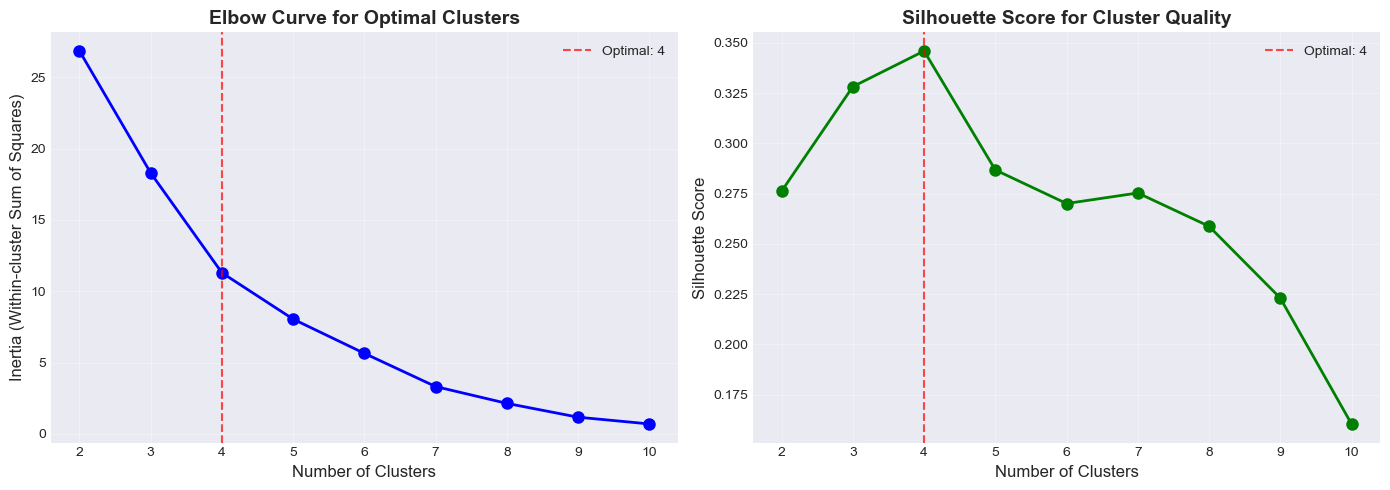

In [34]:
# Visualize elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(cluster_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_clusters, color='r', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_clusters}')
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Curve for Optimal Clusters', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(cluster_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_clusters, color='r', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_clusters}')
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Cluster Quality', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Perform Clustering and Analyze Clusters

In [35]:
# Perform final clustering with optimal number of clusters
kmeans_final = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(factor_scores)

# Add cluster labels to the factor scores dataframe
factor_scores_with_clusters = pd.DataFrame(factor_scores, columns=[f"Factor {i+1}" for i in range(optimal_factors)])
factor_scores_with_clusters['Cluster'] = cluster_labels
factor_scores_with_clusters['Country'] = df_raw.loc[df_clean.index, 'B_COUNTRY_ALPHA'].values if 'B_COUNTRY_ALPHA' in df_raw.columns else range(len(factor_scores_with_clusters))

print(f"Clustering completed with {optimal_clusters} clusters")
print(f"\nCluster distribution:")
print(factor_scores_with_clusters['Cluster'].value_counts().sort_index())
print(f"\nFirst few rows:")
print(factor_scores_with_clusters.head(10))

# Calculate cluster centroids
centroids = kmeans_final.cluster_centers_
centroids_df = pd.DataFrame(
    centroids,
    columns=[f"Factor {i+1}" for i in range(optimal_factors)]
)
centroids_df['Cluster'] = range(optimal_clusters)

print(f"\nCluster Centroids (Factor Scores):")
print(centroids_df)


Clustering completed with 4 clusters

Cluster distribution:
Cluster
0    5
1    5
2    1
3    2
Name: count, dtype: int64

First few rows:
   Factor 1  Factor 2  Factor 3  Cluster      Country
0  0.888913  0.693134 -0.054373        0    Argentina
1 -0.789599  0.042639  2.187420        3   Bangladesh
2  1.543441 -0.211651  0.523737        0      Czechia
3 -1.076496 -0.759420  0.314068        1    Indonesia
4 -0.797882 -1.507780 -0.926786        1        India
5 -0.935495  1.616512 -1.792944        2        Libya
6 -0.365758  1.689607  0.974141        3     Maldives
7 -0.369095 -0.602833 -0.812734        1     Malaysia
8 -1.025532 -0.026407 -0.759567        1      Nigeria
9  1.926812 -1.023644 -0.752431        0  Netherlands

Cluster Centroids (Factor Scores):
   Factor 1  Factor 2  Factor 3  Cluster
0  1.177478  0.156891 -0.028421        0
1 -0.759307 -0.826643 -0.245303        1
2 -0.935495  1.616512 -1.792944        2
3 -0.577679  0.866123  1.580781        3


In [36]:
# Analyze cluster characteristics and generate cluster profiles
print("\n" + "=" * 120)
print("CLUSTER PROFILE ANALYSIS")
print("=" * 120)

cluster_profiles = {}

for cluster_id in range(optimal_clusters):
    print(f"\n{'='*120}")
    print(f"CLUSTER {cluster_id}")
    print('='*120)
    
    # Get countries in this cluster
    cluster_countries = factor_scores_with_clusters[factor_scores_with_clusters['Cluster'] == cluster_id]['Country'].tolist()
    cluster_size = len(cluster_countries)
    
    print(f"\nCluster Size: {cluster_size} countries")
    print(f"Countries: {', '.join(cluster_countries)}")
    
    # Get cluster centroid (mean factor scores)
    centroid = centroids[cluster_id]
    
    print(f"\nCluster Centroid (Mean Factor Scores):")
    for factor_idx, score in enumerate(centroid):
        factor_col = f"Factor {factor_idx + 1}"
        theme = factor_names[factor_col]
        direction = "HIGH" if score > 0.2 else "LOW" if score < -0.2 else "MODERATE"
        print(f"  {factor_col} ({theme:20s}): {score:7.4f}  [{direction}]")
    
    # Get countries in cluster with their factor scores
    cluster_members = factor_scores_with_clusters[factor_scores_with_clusters['Cluster'] == cluster_id][['Country', 'Factor 1', 'Factor 2', 'Factor 3']]
    
    print(f"\nCluster Members Details:")
    print(cluster_members.to_string(index=False))
    
    # Generate cluster profile (strengths and weaknesses based on centroid)
    strengths = []
    weaknesses = []
    
    for factor_idx, score in enumerate(centroid):
        factor_col = f"Factor {factor_idx + 1}"
        theme = factor_names[factor_col]
        
        if score > 0.3:
            strengths.append(f"high {theme.lower()}")
        elif score < -0.3:
            weaknesses.append(f"low {theme.lower()}")
    
    cluster_profiles[cluster_id] = {
        'countries': cluster_countries,
        'size': cluster_size,
        'centroid': centroid,
        'strengths': strengths,
        'weaknesses': weaknesses
    }



CLUSTER PROFILE ANALYSIS

CLUSTER 0

Cluster Size: 5 countries
Countries: Argentina, Czechia, Netherlands, Slovakia, Ukraine

Cluster Centroid (Mean Factor Scores):
  Factor 1 (Religious           ):  1.1775  [HIGH]
  Factor 2 (Trust               ):  0.1569  [MODERATE]
  Factor 3 (Participation       ): -0.0284  [MODERATE]

Cluster Members Details:
    Country  Factor 1  Factor 2  Factor 3
  Argentina  0.888913  0.693134 -0.054373
    Czechia  1.543441 -0.211651  0.523737
Netherlands  1.926812 -1.023644 -0.752431
   Slovakia  0.888166  0.302777  0.125236
    Ukraine  0.640058  1.023841  0.015727

CLUSTER 1

Cluster Size: 5 countries
Countries: Indonesia, India, Malaysia, Nigeria, Philippines

Cluster Centroid (Mean Factor Scores):
  Factor 1 (Religious           ): -0.7593  [LOW]
  Factor 2 (Trust               ): -0.8266  [LOW]
  Factor 3 (Participation       ): -0.2453  [LOW]

Cluster Members Details:
    Country  Factor 1  Factor 2  Factor 3
  Indonesia -1.076496 -0.759420  0.3140

In [37]:
# Generate semantic names and descriptions for clusters
cluster_names = {}
cluster_descriptions = {}

def generate_cluster_name_and_description(cluster_id, profile, factor_names):
    """Generate cluster name and description based on factor characteristics"""
    
    centroid = profile['centroid']
    countries = profile['countries']
    
    # Create profile based on dominant factors
    factor_profiles = {}
    for factor_idx, score in enumerate(centroid):
        factor_col = f"Factor {factor_idx + 1}"
        theme = factor_names[factor_col]
        factor_profiles[theme] = score
    
    # Sort by absolute value to find dominant characteristics
    sorted_factors = sorted(factor_profiles.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Generate cluster name based on strongest characteristics
    dominant_theme = sorted_factors[0][0] if sorted_factors else "Diverse"
    
    # Create intuitive cluster names based on combinations
    high_factors = [theme for theme, score in sorted_factors if score > 0.2]
    low_factors = [theme for theme, score in sorted_factors if score < -0.2]
    
    # Name the cluster
    if len(high_factors) >= 2:
        cluster_name = f"{high_factors[0]} & {high_factors[1].lower()} Emphasis"
    elif high_factors:
        cluster_name = f"High {high_factors[0]}"
    elif low_factors:
        cluster_name = f"Low {low_factors[0]}"
    else:
        cluster_name = "Balanced Values"
    
    # Generate three-sentence description
    overview = f"This cluster comprises {len(countries)} countries ({', '.join(countries)}) with a distinctive values profile."
    
    # Strengths
    if high_factors:
        strength_str = f"This cluster is characterized by strong emphasis on {', '.join(high_factors).lower()}, indicating societies with high prioritization of these dimensions."
    else:
        strength_str = "This cluster shows a balanced approach across multiple dimensions without extreme values in any direction."
    
    # Weaknesses
    if low_factors:
        weakness_str = f"Conversely, this cluster demonstrates relatively low levels of {', '.join(low_factors).lower()}, which may indicate limited institutional development or cultural differences in these areas."
    else:
        weakness_str = "The cluster lacks pronounced weaknesses, suggesting a well-rounded societal profile without significant gaps."
    
    description = f"{overview} {strength_str} {weakness_str}"
    
    return cluster_name, description

# Generate names and descriptions for all clusters
for cluster_id in range(optimal_clusters):
    name, description = generate_cluster_name_and_description(
        cluster_id, 
        cluster_profiles[cluster_id],
        factor_names
    )
    cluster_names[cluster_id] = name
    cluster_descriptions[cluster_id] = description

# Display cluster names and descriptions
print("\n" + "=" * 120)
print("CLUSTER NAMES AND DESCRIPTIONS")
print("=" * 120)

for cluster_id in range(optimal_clusters):
    print(f"\nCLUSTER {cluster_id}: {cluster_names[cluster_id]}")
    print("-" * 120)
    print(cluster_descriptions[cluster_id])
    print()



CLUSTER NAMES AND DESCRIPTIONS

CLUSTER 0: High Religious
------------------------------------------------------------------------------------------------------------------------
This cluster comprises 5 countries (Argentina, Czechia, Netherlands, Slovakia, Ukraine) with a distinctive values profile. This cluster is characterized by strong emphasis on religious, indicating societies with high prioritization of these dimensions. The cluster lacks pronounced weaknesses, suggesting a well-rounded societal profile without significant gaps.


CLUSTER 1: Low Trust
------------------------------------------------------------------------------------------------------------------------
This cluster comprises 5 countries (Indonesia, India, Malaysia, Nigeria, Philippines) with a distinctive values profile. This cluster shows a balanced approach across multiple dimensions without extreme values in any direction. Conversely, this cluster demonstrates relatively low levels of trust, religious, part

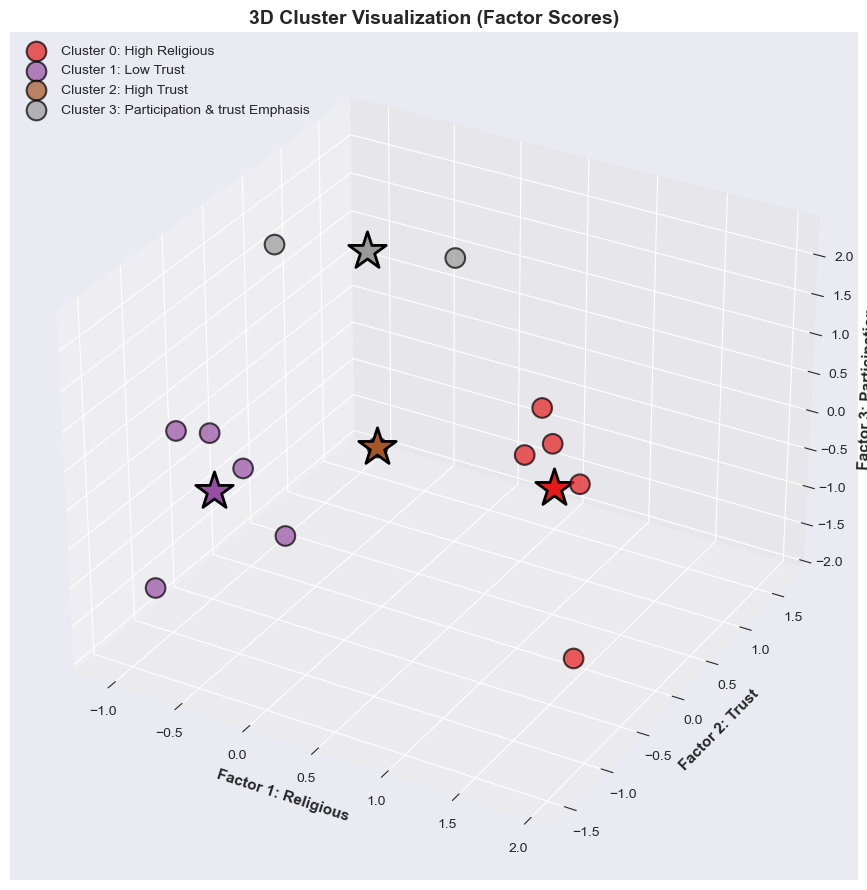

✓ 3D visualization complete


In [40]:
# Visualization: 3D scatter plot of clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Define colors for clusters
colors = plt.cm.Set1(np.linspace(0, 1, optimal_clusters))

# Plot each cluster
for cluster_id in range(optimal_clusters):
    cluster_mask = cluster_labels == cluster_id
    ax.scatter(
        factor_scores[cluster_mask, 0],
        factor_scores[cluster_mask, 1],
        factor_scores[cluster_mask, 2],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}: {cluster_names[cluster_id]}',
        s=200,
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5
    )
    
    # Plot centroid
    ax.scatter(
        centroids[cluster_id, 0],
        centroids[cluster_id, 1],
        centroids[cluster_id, 2],
        c=[colors[cluster_id]],
        marker='*',
        s=800,
        edgecolors='black',
        linewidth=2
    )

ax.set_xlabel('Factor 1: Religious', fontsize=11, fontweight='bold')
ax.set_ylabel('Factor 2: Trust', fontsize=11, fontweight='bold')
ax.set_zlabel('Factor 3: Participation', fontsize=11, fontweight='bold')
ax.set_title('3D Cluster Visualization (Factor Scores)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ 3D visualization complete")


In [41]:
# Export cluster results
cluster_results_file = 'cluster_analysis_results.txt'

with open(cluster_results_file, 'w') as f:
    f.write("=" * 120 + "\n")
    f.write("CLUSTER ANALYSIS RESULTS - WORLD VALUES SURVEY (WVS)\n")
    f.write("=" * 120 + "\n\n")
    
    f.write(f"Optimal Number of Clusters: {optimal_clusters}\n")
    f.write(f"Clustering Method: K-Means\n")
    f.write(f"Silhouette Score: {max(silhouette_scores):.4f}\n\n")
    
    f.write("=" * 120 + "\n")
    f.write("CLUSTER SUMMARIES\n")
    f.write("=" * 120 + "\n\n")
    
    for cluster_id in range(optimal_clusters):
        f.write(f"CLUSTER {cluster_id}: {cluster_names[cluster_id]}\n")
        f.write("-" * 120 + "\n")
        f.write(cluster_descriptions[cluster_id] + "\n\n")
        
        profile = cluster_profiles[cluster_id]
        f.write(f"Countries in Cluster ({len(profile['countries'])}): {', '.join(profile['countries'])}\n\n")
        
        f.write("Factor Scores (Centroid):\n")
        centroid = profile['centroid']
        for factor_idx, score in enumerate(centroid):
            factor_col = f"Factor {factor_idx + 1}"
            theme = factor_names[factor_col]
            f.write(f"  {factor_col} ({theme}): {score:7.4f}\n")
        f.write("\n\n")
    
    f.write("=" * 120 + "\n")
    f.write("DETAILED CLUSTER MEMBERSHIP\n")
    f.write("=" * 120 + "\n\n")
    f.write(factor_scores_with_clusters[['Country', 'Factor 1', 'Factor 2', 'Factor 3', 'Cluster']].to_string(index=False))

# Save cluster assignments
factor_scores_with_clusters.to_csv('country_cluster_assignments.csv', index=False)

print("✓ Cluster analysis results exported:")
print(f"  - Cluster summary: {cluster_results_file}")
print(f"  - Cluster assignments: country_cluster_assignments.csv")
print(f"\nCluster Summary:")
for cluster_id in range(optimal_clusters):
    profile = cluster_profiles[cluster_id]
    print(f"\n  Cluster {cluster_id}: {cluster_names[cluster_id]}")
    print(f"    Countries: {', '.join(profile['countries'])}")
    print(f"    Size: {profile['size']} countries")


✓ Cluster analysis results exported:
  - Cluster summary: cluster_analysis_results.txt
  - Cluster assignments: country_cluster_assignments.csv

Cluster Summary:

  Cluster 0: High Religious
    Countries: Argentina, Czechia, Netherlands, Slovakia, Ukraine
    Size: 5 countries

  Cluster 1: Low Trust
    Countries: Indonesia, India, Malaysia, Nigeria, Philippines
    Size: 5 countries

  Cluster 2: High Trust
    Countries: Libya
    Size: 1 countries

  Cluster 3: Participation & trust Emphasis
    Countries: Bangladesh, Maldives
    Size: 2 countries


## 10. Country Profile Analysis - Argentina

In [44]:
# Analyze Argentina's profile
argentina_data = factor_scores_with_clusters[factor_scores_with_clusters['Country'] == 'Argentina']

if len(argentina_data) > 0:
    print("=" * 100)
    print("COUNTRY PROFILE: ARGENTINA")
    print("=" * 100)
    
    arg_row = argentina_data.iloc[0]
    arg_cluster = int(arg_row['Cluster'])
    arg_religious = arg_row['Factor 1']
    arg_trust = arg_row['Factor 2']
    arg_participation = arg_row['Factor 3']
    
    print(f"\nCluster Assignment: Cluster {arg_cluster}")
    print(f"Cluster Name: {cluster_names[arg_cluster]}")
    print(f"\nFactor Scores:")
    print(f"  Factor 1 (Religious):      {arg_religious:7.4f}")
    print(f"  Factor 2 (Trust):          {arg_trust:7.4f}")
    print(f"  Factor 3 (Participation):  {arg_participation:7.4f}")
    
    # Interpret scores
    print(f"\nScore Interpretation:")
    print(f"  Religious:      {'HIGH (+)' if arg_religious > 0.2 else 'MODERATE' if arg_religious > -0.2 else 'LOW (-)'}")
    print(f"  Trust:          {'HIGH (+)' if arg_trust > 0.2 else 'MODERATE' if arg_trust > -0.2 else 'LOW (-)'}")
    print(f"  Participation:  {'HIGH (+)' if arg_participation > 0.2 else 'MODERATE' if arg_participation > -0.2 else 'LOW (-)'}")
    
    # Generate Argentina-specific three-sentence summary
    print(f"\n" + "=" * 100)
    print("THREE-SENTENCE SUMMARY FOR ARGENTINA")
    print("=" * 100)
    
    # Identify strengths (high positive factors)
    strengths = []
    if arg_religious > 0.2:
        strengths.append("high religious engagement")
    if arg_trust > 0.2:
        strengths.append("strong interpersonal trust")
    if arg_participation > 0.2:
        strengths.append("active social participation")
    
    # Identify weaknesses (low negative factors)
    weaknesses = []
    if arg_religious < -0.2:
        weaknesses.append("limited religious importance")
    if arg_trust < -0.2:
        weaknesses.append("lower institutional trust levels")
    if arg_participation < -0.2:
        weaknesses.append("reduced community participation")
    
    # Identify moderate factors
    moderate = []
    if -0.2 <= arg_religious <= 0.2:
        moderate.append("religious values")
    if -0.2 <= arg_trust <= 0.2:
        moderate.append("trust in institutions")
    if -0.2 <= arg_participation <= 0.2:
        moderate.append("community participation")
    
    # Sentence 1: Strengths
    if strengths:
        sentence1 = f"Argentina demonstrates particular strength in {' and '.join(strengths)}, reflecting a society that highly values religious engagement and interpersonal trust."
    else:
        sentence1 = f"Argentina presents a balanced profile without pronounced strengths in any single dimension."
    
    # Sentence 2: Weaknesses/Average
    if weaknesses:
        sentence2 = f"The country shows relatively moderate levels in {' and '.join(weaknesses)}, suggesting these areas may require development attention."
    else:
        if moderate:
            sentence2 = f"Argentina maintains moderate levels in {', '.join(moderate)}, neither particularly strong nor weak in these dimensions, indicating a middle-ground approach."
        else:
            sentence2 = f"The country maintains balanced levels across all measured dimensions."
    
    # Sentence 3: Conclusion
    cluster_profile = cluster_profiles[arg_cluster]
    sentence3 = f"Overall, Argentina belongs to the '{cluster_names[arg_cluster].lower()}' cluster, positioning it among countries with similar value profiles ({', '.join(cluster_profile['countries'])})."
    
    print(f"\n1. STRENGTHS:\n   {sentence1}\n")
    print(f"2. WEAKNESSES/AVERAGE:\n   {sentence2}\n")
    print(f"3. CONCLUSION:\n   {sentence3}\n")
    
else:
    print("Argentina not found in the dataset.")


COUNTRY PROFILE: ARGENTINA

Cluster Assignment: Cluster 0
Cluster Name: High Religious

Factor Scores:
  Factor 1 (Religious):       0.8889
  Factor 2 (Trust):           0.6931
  Factor 3 (Participation):  -0.0544

Score Interpretation:
  Religious:      HIGH (+)
  Trust:          HIGH (+)
  Participation:  MODERATE

THREE-SENTENCE SUMMARY FOR ARGENTINA

1. STRENGTHS:
   Argentina demonstrates particular strength in high religious engagement and strong interpersonal trust, reflecting a society that highly values religious engagement and interpersonal trust.

2. WEAKNESSES/AVERAGE:
   Argentina maintains moderate levels in community participation, neither particularly strong nor weak in these dimensions, indicating a middle-ground approach.

3. CONCLUSION:
   Overall, Argentina belongs to the 'high religious' cluster, positioning it among countries with similar value profiles (Argentina, Czechia, Netherlands, Slovakia, Ukraine).

